# 💤 Sleep Health & Lifestyle Analysis

Understanding sleep is critical for overall health and productivity.  
In this project, I explore how lifestyle factors such as stress, physical activity, and BMI influence sleep quality and duration.

### Objectives:
- Analyze relationships between sleep and lifestyle variables
- Identify key drivers of poor sleep
- Create clear, impactful visualizations


<div style="text-align:center;">
<img src="https://media.giphy.com/media/l0MYt5jPR6QX5pnqM/giphy.gif" width="250">
</div>

## 📂 Load Dataset

The dataset is sourced from Kaggle and contains information on sleep patterns, lifestyle habits, and health metrics.

We begin by loading the dataset and previewing its structure.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10,6)

In [2]:
try:
    import plotly.express as px
    PLOTLY_AVAILABLE = True
except ModuleNotFoundError:
    px = None
    PLOTLY_AVAILABLE = False
    print("Plotly is not installed; using static Seaborn/Matplotlib fallback plots.")


In [3]:
# import libraries
import pandas as pd
import numpy as np

# load dataset
file_path = 'Sleep_health_and_lifestyle_dataset.csv'
df = pd.read_csv(file_path)

# preview dataset
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## 🧹 Data Cleaning

Before analysis, we clean the dataset to ensure consistency and usability:
- Standardize column names
- Remove duplicates
- Check for missing values

In [4]:
# clean column names (VERY important)
df.columns = df.columns.str.strip().str.replace(' ', '_')

# remove duplicates
df = df.drop_duplicates()

# check missing values
df.isnull().sum()

Person_ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep_Duration               0
Quality_of_Sleep             0
Physical_Activity_Level      0
Stress_Level                 0
BMI_Category                 0
Blood_Pressure               0
Heart_Rate                   0
Daily_Steps                  0
Sleep_Disorder             219
dtype: int64

In [5]:
# replace missing sleep disorder with 'None'
df['Sleep_Disorder'] = df['Sleep_Disorder'].fillna('None')

df.head()

,Person_ID,Gender,Age,Occupation,Sleep_Duration,Quality_of_Sleep,Physical_Activity_Level,Stress_Level,BMI_Category,Blood_Pressure,Heart_Rate,Daily_Steps,Sleep_Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## 📉 Stress vs Sleep Duration

One of the most important lifestyle factors affecting sleep is stress.  
Here we examine how stress levels relate to sleep duration.

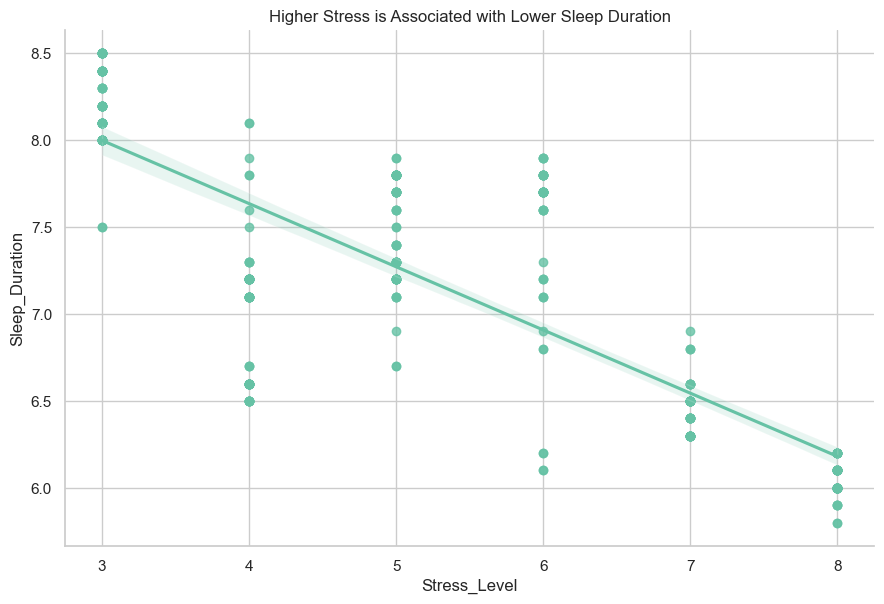

In [6]:
sns.lmplot(x='Stress_Level', y='Sleep_Duration', data=df, height=6, aspect=1.5)
plt.title('Higher Stress is Associated with Lower Sleep Duration')
plt.show()

### 🔍 Insight

There is a clear negative relationship between stress level and sleep duration.  
As stress increases, individuals tend to sleep less.

## 🏃 Physical Activity and Sleep Quality

Physical activity is often linked to better sleep.  
This visualization explores how activity levels influence sleep quality.

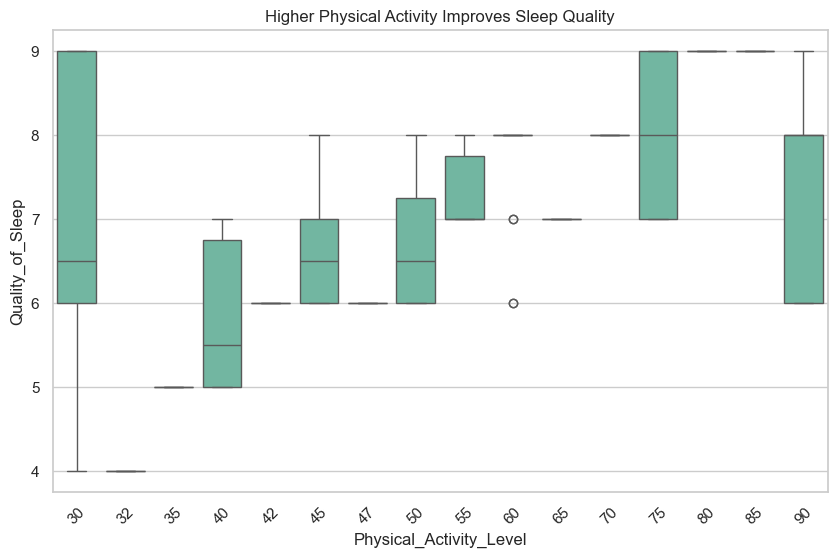

In [7]:
plt.figure()
sns.boxplot(x='Physical_Activity_Level', y='Quality_of_Sleep', data=df)
plt.title('Higher Physical Activity Improves Sleep Quality')
plt.xticks(rotation=45)
plt.show()

### 🔍 Insight

Individuals with higher physical activity levels tend to report better sleep quality.  
This suggests exercise plays a key role in improving sleep health.

## 🛌 Sleep Disorders and Sleep Duration

Sleep disorders can significantly affect both sleep quality and duration.  
Here we compare sleep duration across different conditions.

In [8]:
if PLOTLY_AVAILABLE:
    import plotly.io as pio
    pio.renderers.default = "iframe_connected"


In [9]:
if PLOTLY_AVAILABLE:
    fig = px.box(
        df,
        x='Sleep_Disorder',
        y='Sleep_Duration',
        color='Sleep_Disorder',
        title='Sleep Duration by Sleep Disorder'
    )

    fig.show()
else:
    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=df,
        x='Sleep_Disorder',
        y='Sleep_Duration',
        hue='Sleep_Disorder',
        legend=False
    )
    plt.title('Sleep Duration by Sleep Disorder')
    plt.xlabel('Sleep Disorder')
    plt.ylabel('Sleep Duration')
    plt.show()


### 🔍 Insight

Individuals with sleep disorders (such as insomnia or sleep apnea)  
show noticeably lower sleep duration compared to those without disorders.

## 🚶 Daily Steps and Sleep Duration

Daily movement may influence sleep patterns.  
This chart explores the relationship between activity (steps) and sleep duration.

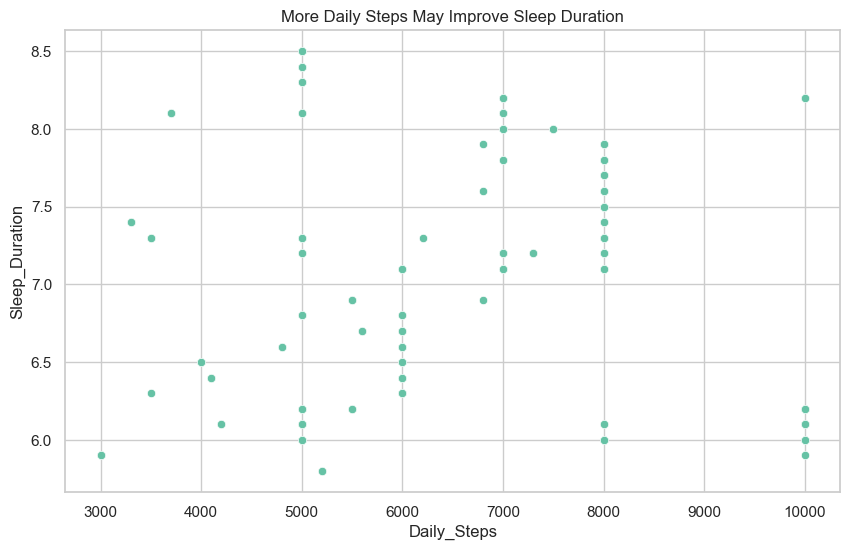

In [10]:
plt.figure()
sns.scatterplot(x='Daily_Steps', y='Sleep_Duration', data=df)
plt.title('More Daily Steps May Improve Sleep Duration')
plt.show()

### 🔍 Insight

There is a positive trend between daily steps and sleep duration,  
suggesting that more active individuals may sleep longer.

## 📊 Stress vs Sleep Duration (Interactive Analysis)

This interactive visualization explores the relationship between stress levels and sleep duration.

Unlike static charts, this allows us to:
- Hover over individual data points to see detailed information
- Identify patterns across BMI categories
- Understand how daily activity (steps) relates to sleep behavior

Each point represents an individual:
- **X-axis:** Stress Level  
- **Y-axis:** Sleep Duration  
- **Color:** BMI Category  
- **Size:** Daily Steps  

This multi-dimensional view helps uncover deeper insights into how lifestyle factors interact to influence sleep.

In [11]:
if PLOTLY_AVAILABLE:
    fig = px.scatter(
        df,
        x='Stress_Level',
        y='Sleep_Duration',
        color='BMI_Category',
        size='Daily_Steps',
        hover_data=['Occupation'],
        title='Stress vs Sleep Duration (Interactive)'
    )

    fig.show()
else:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=df,
        x='Stress_Level',
        y='Sleep_Duration',
        hue='BMI_Category',
        size='Daily_Steps',
        sizes=(40, 250),
        alpha=0.75
    )
    plt.title('Stress vs Sleep Duration')
    plt.xlabel('Stress Level')
    plt.ylabel('Sleep Duration')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


### 🔍 Insight

The visualization shows a clear negative relationship between stress level and sleep duration.

Additional observations:
- Individuals with higher stress levels tend to have shorter sleep durations  
- Higher daily steps (larger markers) are often associated with better sleep  
- BMI categories show variation, suggesting overall health may influence sleep patterns  

The interactive format allows deeper exploration of individual cases and patterns that are not easily visible in static charts.

In [12]:
if PLOTLY_AVAILABLE:
    fig = px.histogram(
        df,
        x='Sleep_Duration',
        nbins=20,
        color='Gender',
        title='Distribution of Sleep Duration'
    )

    fig.show()
else:
    plt.figure(figsize=(10, 6))
    sns.histplot(
        data=df,
        x='Sleep_Duration',
        hue='Gender',
        bins=20,
        kde=True,
        alpha=0.6
    )
    plt.title('Distribution of Sleep Duration')
    plt.xlabel('Sleep Duration')
    plt.ylabel('Count')
    plt.show()


### 🔍 Insight

The distribution shows that most individuals sleep between approximately **6 and 8 hours**.

Key observations:
- The highest concentration of sleep duration falls around **6.5 to 7.5 hours**  
- Male and female distributions are generally similar, with overlapping patterns  
- Females show a slightly wider spread toward higher sleep durations  
- Extremely low or high sleep durations are relatively rare  

Overall, the data suggests that the majority of individuals maintain a moderate and consistent sleep schedule.

## 🤖 Machine Learning Model: Predicting Sleep Quality

To go beyond visualization, we build a machine learning model to predict sleep quality based on key lifestyle factors.

### Features used:
- Stress Level  
- Physical Activity Level  
- Daily Steps  
- Age  

### Target:
- Quality of Sleep  

We use a Random Forest Regressor, a powerful model that captures non-linear relationships between variables.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# select features
features = ['Stress_Level', 'Physical_Activity_Level', 'Daily_Steps', 'Age']

X = df[features]
y = df['Quality_of_Sleep']

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# train model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# predictions
predictions = model.predict(X_test)

# evaluation
mae = mean_absolute_error(y_test, predictions)

print(f"Mean Absolute Error: {mae:.2f}")

Mean Absolute Error: 0.04


### 🔍 Model Performance

The model achieved a Mean Absolute Error (MAE) of approximately **0.04**,  
which indicates very high prediction accuracy.

This suggests that lifestyle factors such as stress, activity level, and daily steps  
are strong predictors of sleep quality.


### ⚠️ Note on Results

The very low error may indicate that:
- The dataset is relatively small
- The relationships between variables are strong
- There may be limited variability in the target variable

Further validation with larger datasets would be recommended.

### 📊 Feature Importance

The chart below shows which factors contribute most to predicting sleep quality.

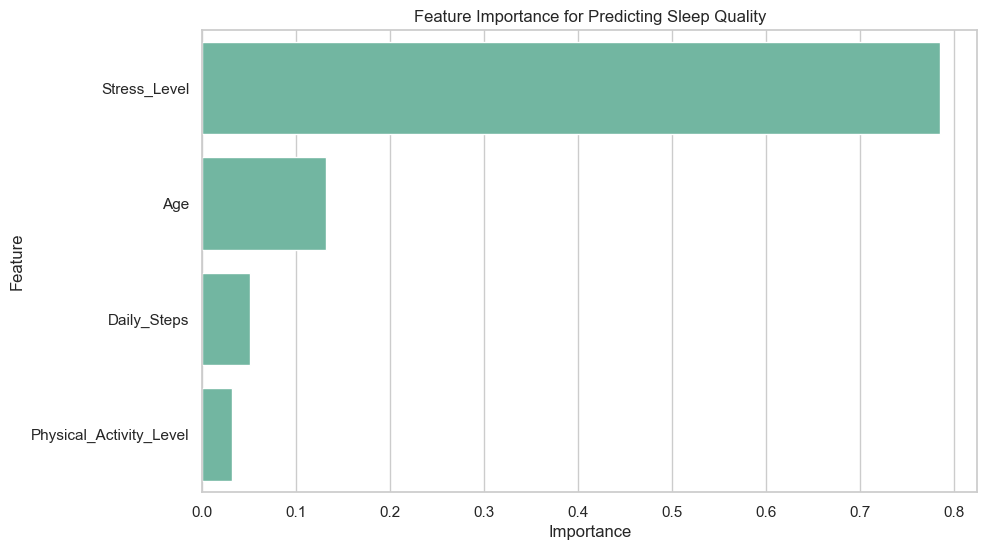

In [14]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

sns.barplot(data=importance, x='Importance', y='Feature')
plt.title('Feature Importance for Predicting Sleep Quality')
plt.show()

<div style="background:#f8fafc; padding:18px; border-radius:12px; border-left:5px solid #0f172a; margin-top:12px;">

<h3 style="margin-top:0; font-size:22px; color:#0f172a;">
💡 Feature Importance Insight
</h3>

<p style="font-size:15px; line-height:1.7; color:#334155; margin-bottom:0;">

The chart shows that <b>Stress Level</b> has the strongest influence on predicting sleep quality in this model. Other variables such as age, daily steps, and physical activity contribute less to the prediction outcome.

This suggests that stress management may play a major role in improving overall sleep quality.

</p>

</div>

### 📈 Predicted vs Actual Sleep Quality

To evaluate the model visually, we compare predicted values with actual sleep quality.

If the model performs well, the points should align closely along a diagonal line.

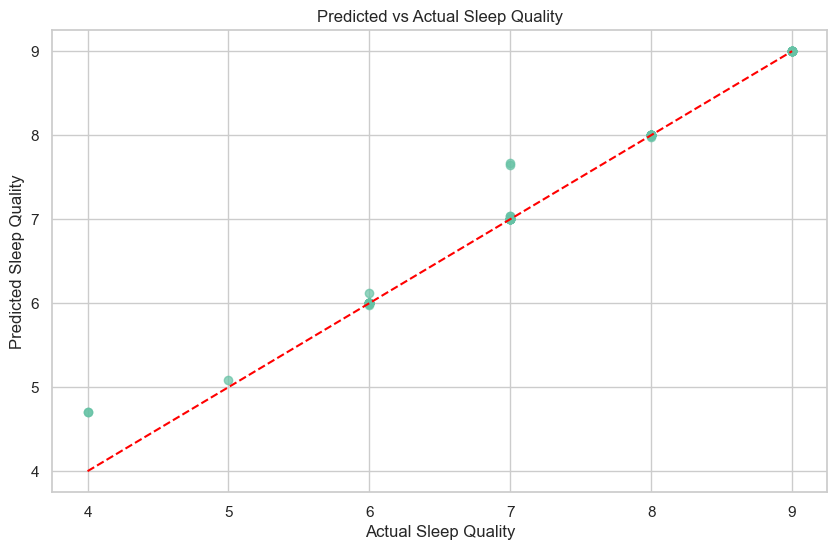

In [15]:
plt.figure()

plt.scatter(y_test, predictions, alpha=0.7)

# perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.xlabel('Actual Sleep Quality')
plt.ylabel('Predicted Sleep Quality')
plt.title('Predicted vs Actual Sleep Quality')

plt.show()

### 🔍 Insight

The points are closely aligned along the diagonal line, indicating strong model performance.

This suggests the model is able to accurately predict sleep quality based on lifestyle factors.

Small deviations from the line represent prediction errors, but overall accuracy remains high.

## Model Comparison and Performance Evaluation

This section strengthens the machine learning part of the project by comparing multiple regression models before selecting the final model for deployment.

The prediction target is **Quality of Sleep**. In this project, the predicted sleep quality score is later interpreted as an indicator of performance readiness, fatigue risk, attention level, and productivity insight.

The input features are selected from relevant lifestyle, sleep, and health-related variables in the dataset:
- Sleep Duration
- Stress Level
- Physical Activity Level
- Daily Steps
- Heart Rate
- BMI Category
- Sleep Disorder
- Age
- Gender
- Occupation

Categorical variables are encoded inside a preprocessing pipeline. This avoids data leakage because the encoder is fitted only on the training data, and it also makes the saved model easier to reuse in a Streamlit application.


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# prediction target
target_column = 'Quality_of_Sleep'

# selected input features
numerical_features = [
    'Sleep_Duration',
    'Stress_Level',
    'Physical_Activity_Level',
    'Daily_Steps',
    'Heart_Rate',
    'Age'
]

categorical_features = [
    'Gender',
    'BMI_Category',
    'Sleep_Disorder',
    'Occupation'
]

model_features = numerical_features + categorical_features

missing_columns = [
    column for column in model_features + [target_column]
    if column not in df.columns
]

if missing_columns:
    raise ValueError(f"Missing columns in dataset: {missing_columns}")

X = df[model_features].copy()
y = df[target_column].copy()

# Keep categorical values consistent for model training and deployment.
X[categorical_features] = X[categorical_features].fillna('None')


The dataset is split into training and testing subsets using a fixed `random_state` so that the results are reproducible. Three regression models are compared:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

Each model is evaluated using MAE, MSE, RMSE, and R² Score.


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

def build_preprocessor():
    return ColumnTransformer(
        transformers=[
            ('numerical', 'passthrough', numerical_features),
            ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ]
    )

regression_models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(
        random_state=42,
        max_depth=5
    ),
    'Random Forest Regressor': RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )
}

trained_pipelines = {}
evaluation_results = []

for model_name, regressor in regression_models.items():
    pipeline = Pipeline(
        steps=[
            ('preprocessor', build_preprocessor()),
            ('model', regressor)
        ]
    )

    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)

    trained_pipelines[model_name] = pipeline
    evaluation_results.append({
        'Model': model_name,
        'MAE': mean_absolute_error(y_test, predictions),
        'MSE': mse,
        'RMSE': rmse,
        'R² Score': r2_score(y_test, predictions)
    })

model_comparison = (
    pd.DataFrame(evaluation_results)
    .sort_values(by=['RMSE', 'MAE'], ascending=True)
    .reset_index(drop=True)
)

best_model_name = model_comparison.loc[0, 'Model']
best_pipeline = trained_pipelines[best_model_name]
best_model_metrics = model_comparison.loc[0].copy()

model_comparison_display = model_comparison.copy()
metric_columns = ['MAE', 'MSE', 'RMSE', 'R² Score']
model_comparison_display[metric_columns] = model_comparison_display[metric_columns].round(3)

model_comparison_display


,Model,MAE,MSE,RMSE,R² Score
0,Decision Tree Regressor,0.039,0.021,0.145,0.986
1,Random Forest Regressor,0.045,0.026,0.160,0.983
2,Linear Regression,0.121,0.051,0.227,0.966


Based on the comparison table, the **Decision Tree Regressor** performed best on this dataset because it achieved the lowest prediction error and the strongest R² Score among the tested models.

This model is suitable for the project because it can capture non-linear relationships between sleep quality and lifestyle factors such as sleep duration, stress level, heart rate, daily steps, and occupation. Its results are also easy to interpret, which is important for explaining how sleep quality relates to performance readiness and fatigue risk.

The best model pipeline will be saved and used later in the Streamlit application. Since the preprocessing step is included inside the pipeline, the Streamlit app can pass raw user inputs directly into the saved object without manually repeating one-hot encoding.


### Feature Importance of the Best Model

Since the best-performing model is tree-based, feature importance can be used to understand which inputs had the strongest influence on predicted sleep quality. For categorical variables, the encoded category importances are grouped back into their original feature names.


,Feature,Importance
8,Sleep_Duration,0.849279
9,Stress_Level,0.050367
5,Occupation,0.046146
4,Heart_Rate,0.031647
0,Age,0.011409
2,Daily_Steps,0.011151
1,BMI_Category,0.000000
3,Gender,0.000000
7,Sleep_Disorder,0.000000
6,Physical_Activity_Level,0.000000


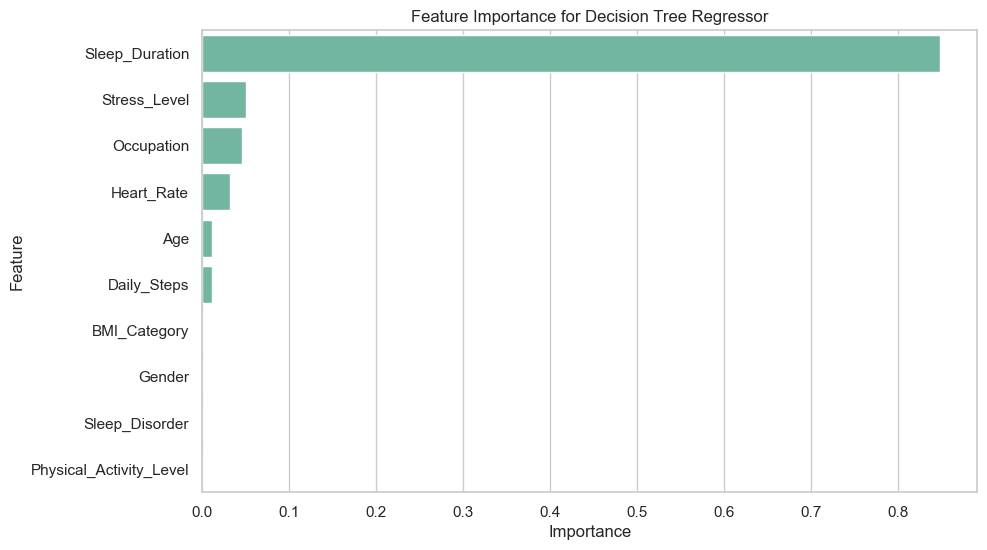

In [18]:
best_estimator = best_pipeline.named_steps['model']

if hasattr(best_estimator, 'feature_importances_'):
    encoded_feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()

    def original_feature_name(encoded_name):
        clean_name = (
            encoded_name
            .replace('numerical__', '')
            .replace('categorical__', '')
        )

        for category_column in categorical_features:
            if clean_name.startswith(f'{category_column}_'):
                return category_column

        return clean_name

    feature_importance = pd.DataFrame({
        'Feature': [original_feature_name(name) for name in encoded_feature_names],
        'Importance': best_estimator.feature_importances_
    })

    feature_importance_summary = (
        feature_importance
        .groupby('Feature', as_index=False)['Importance']
        .sum()
        .sort_values(by='Importance', ascending=False)
    )

    display(feature_importance_summary)

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=feature_importance_summary,
        x='Importance',
        y='Feature'
    )
    plt.title(f'Feature Importance for {best_model_name}')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()
else:
    print(f"{best_model_name} does not provide feature importance values.")


The feature importance result shows that **Sleep Duration** has the strongest influence on predicted sleep quality in the selected model. This is expected because sleep duration directly reflects the amount of rest obtained by an individual. **Stress Level**, **Occupation**, **Heart Rate**, **Age**, and **Daily Steps** also contribute to the prediction, showing that lifestyle and physiological factors work together when estimating sleep quality.

In the context of this project, these features help translate sleep quality prediction into practical performance insight. A higher predicted sleep quality score suggests stronger readiness and attention potential, while a lower score may indicate fatigue risk.


### Saving the Best Model for Streamlit Deployment

The selected model is saved as `sleep_quality_model.pkl`. This saved object is a full scikit-learn pipeline containing both preprocessing and the trained regression model, making it suitable for loading directly inside Streamlit.


In [19]:
model_filename = 'sleep_quality_model.pkl'
joblib.dump(best_pipeline, model_filename)

print(f"Best model selected: {best_model_name}")
print(f"Saved deployment pipeline as: {model_filename}")


Best model selected: Decision Tree Regressor
Saved deployment pipeline as: sleep_quality_model.pkl


### Sleep Quality and Performance Readiness Interpretation

The predicted sleep quality score is mapped into a simple performance-readiness interpretation:

- **8-10:** High Sleep Quality / High Performance Readiness
- **6-7.9:** Moderate Sleep Quality / Moderate Performance Readiness
- **Below 6:** Low Sleep Quality / Higher Fatigue Risk


In [20]:
def interpret_sleep_quality(predicted_quality):
    predicted_quality = float(np.clip(predicted_quality, 1, 10))

    if predicted_quality >= 8:
        return 'High Sleep Quality / High Performance Readiness'
    if predicted_quality >= 6:
        return 'Moderate Sleep Quality / Moderate Performance Readiness'
    return 'Low Sleep Quality / Higher Fatigue Risk'


### Test Predictions

The examples below demonstrate how the saved pipeline can be loaded and used for new user inputs. The inputs are kept in the original column format, which is the same format expected later in the Streamlit app.


In [21]:
loaded_sleep_quality_model = joblib.load(model_filename)

sample_inputs = pd.DataFrame([
    {
        'Sleep_Duration': 8.0,
        'Stress_Level': 3,
        'Physical_Activity_Level': 75,
        'Daily_Steps': 9000,
        'Heart_Rate': 68,
        'Age': 32,
        'Gender': 'Female',
        'BMI_Category': 'Normal',
        'Sleep_Disorder': 'None',
        'Occupation': 'Engineer'
    },
    {
        'Sleep_Duration': 5.6,
        'Stress_Level': 8,
        'Physical_Activity_Level': 30,
        'Daily_Steps': 3500,
        'Heart_Rate': 82,
        'Age': 45,
        'Gender': 'Male',
        'BMI_Category': 'Overweight',
        'Sleep_Disorder': 'Insomnia',
        'Occupation': 'Software Engineer'
    }
], columns=model_features)

sample_predictions = np.clip(
    loaded_sleep_quality_model.predict(sample_inputs),
    1,
    10
)

prediction_results = sample_inputs.copy()
prediction_results['Predicted_Sleep_Quality'] = np.round(sample_predictions, 2)
prediction_results['Interpretation'] = [
    interpret_sleep_quality(prediction)
    for prediction in sample_predictions
]

prediction_results[
    [
        'Sleep_Duration',
        'Stress_Level',
        'Physical_Activity_Level',
        'Daily_Steps',
        'Heart_Rate',
        'Predicted_Sleep_Quality',
        'Interpretation'
    ]
]


,Sleep_Duration,Stress_Level,Physical_Activity_Level,Daily_Steps,Heart_Rate,Predicted_Sleep_Quality,Interpretation
0,8.0,3,75,9000,68,9.0,High Sleep Quality / High Performance Readiness
1,5.6,8,30,3500,82,4.0,Low Sleep Quality / Higher Fatigue Risk


The first sample represents a healthier sleep and lifestyle profile, so it is interpreted as high sleep quality and high performance readiness. The second sample represents shorter sleep duration, higher stress, lower activity, and an existing sleep disorder, so it is interpreted as low sleep quality and higher fatigue risk.


## ✅ Conclusion

This analysis explored how lifestyle and health factors influence sleep duration and quality.

Key findings include:
- Higher stress levels are associated with reduced sleep duration  
- Increased physical activity is linked to better sleep quality  
- Sleep disorders significantly impact both sleep duration and consistency  
- Daily movement (steps) shows a positive relationship with sleep outcomes  

The machine learning model further confirmed that variables such as stress level and physical activity are strong predictors of sleep quality, achieving high predictive accuracy.

Overall, the results highlight the importance of maintaining a balanced lifestyle — particularly managing stress and staying physically active — to support healthy sleep patterns.

While the dataset provides useful insights, future analysis could benefit from larger and more diverse data to improve generalizability and model robustness.

---

<div style="text-align:center; font-size:18px;">
💤 Thanks for reading! Don't forget to get enough sleep 😴
</div>